Failed to read module file 'C:\Users\ghugu\AppData\Roaming\uv\python\cpython-3.12.11-windows-x86_64-none\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\controlling_behaviors_in_animals_and_robots\cobar-2026\Group13\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\controlling_behaviors_in_animals_and_robots\cobar-2026\Group13\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ghugu\AppData\Roaming\uv\python\cpython-3.12.11-windows-x86_64-none\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 13

Failed to read module file 'C:\Users\ghugu\AppData\Roaming\uv\python\cpython-3.12.11-windows-x86_64-none\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\controlling_behaviors_in_animals_and_robots\cobar-2026\Group13\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\controlling_behaviors_in_animals_and_robots\cobar-2026\Group13\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ghugu\AppData\Roaming\uv\python\cpython-3.12.11-windows-x86_64-none\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_impo

Vision obstacle scores: L=-1.0000, R=-1.0000
(512, 450)
right_eye_score: 0, left_eye_score: 0
Dragonfly head detected: False (Left eye)


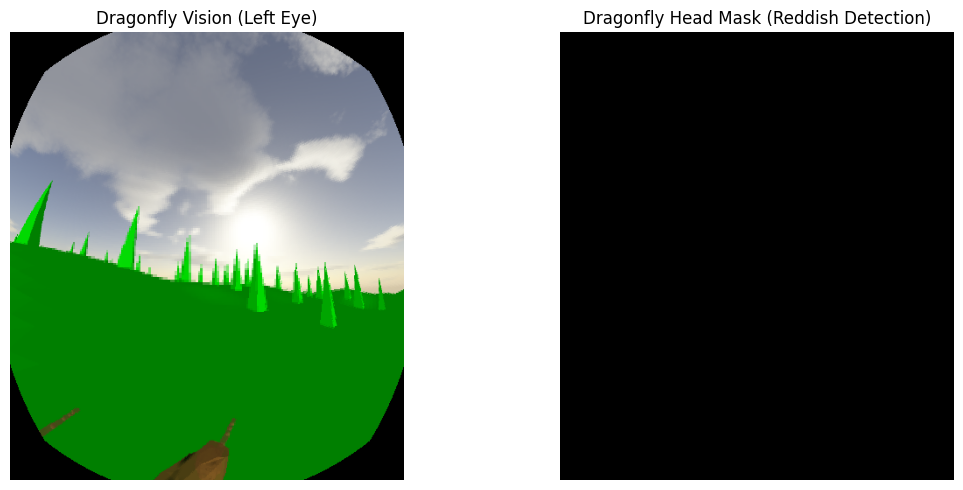

(512, 450)
right_eye_score: 0, left_eye_score: 0
Dragonfly head detected: False (Right eye)


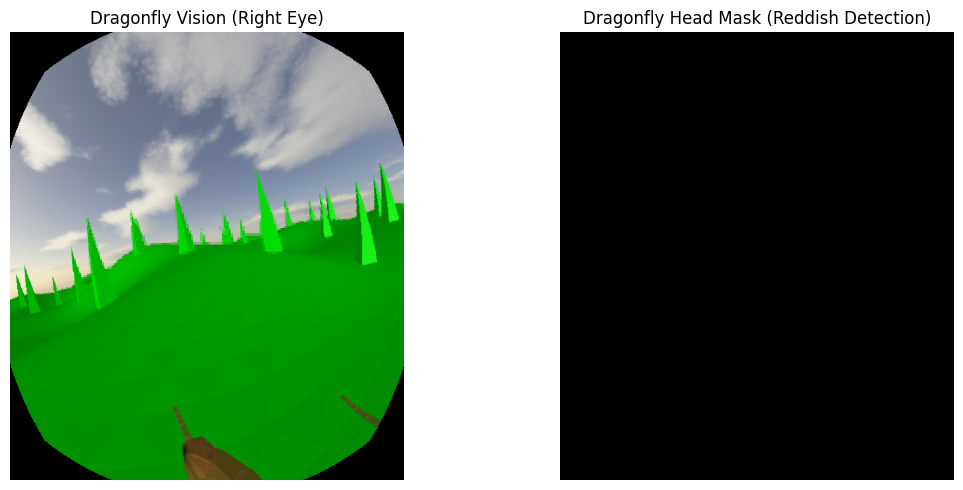

  0%|          | 1/20000 [00:04<24:52:32,  4.48s/it]

Dragonfly head scores: Left=0, Right=0, Detected=False
Dragonfly head detected! Starting dodge maneuver.


 25%|██▍       | 4991/20000 [00:17<00:39, 378.98it/s]

Vision obstacle scores: L=-1.0000, R=-1.0000
(512, 450)
right_eye_score: 0, left_eye_score: 43
Dragonfly head detected: True (Left eye)


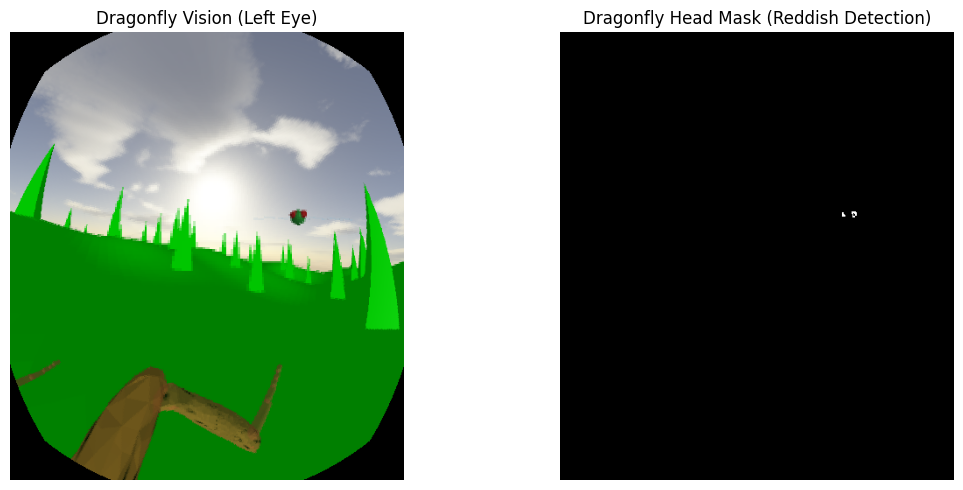

Dragonfly head scores: Left=43, Right=0, Detected=True
Olfaction ratio: 1.0227974018572257e-15
FOLLOW_SCENT: turning left


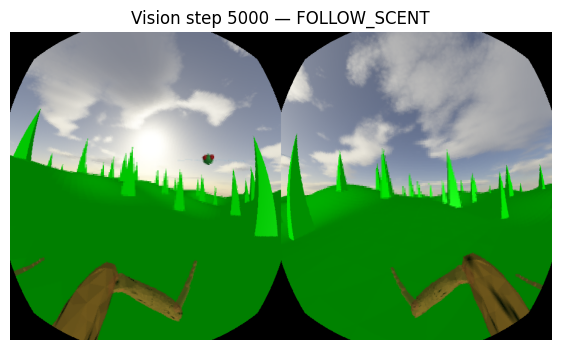

 50%|████▉     | 9971/20000 [00:31<00:24, 406.51it/s]

Vision obstacle scores: L=-1.0000, R=-1.0000
(512, 450)
right_eye_score: 0, left_eye_score: 149
Dragonfly head detected: True (Left eye)


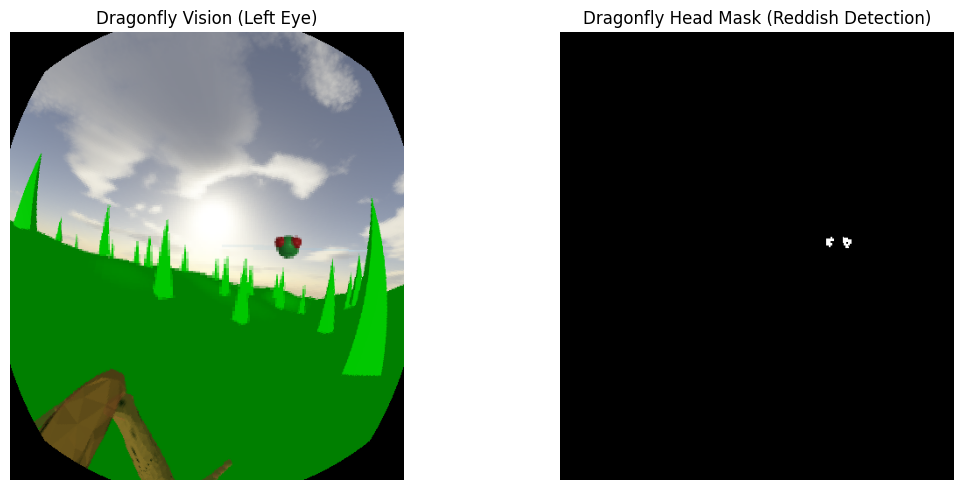

Dragonfly head scores: Left=149, Right=0, Detected=True


 75%|███████▍  | 14966/20000 [00:49<00:15, 334.40it/s]

Eye 1: obstacle_y=60, obstacle_width=52
ends - starts [18 52]


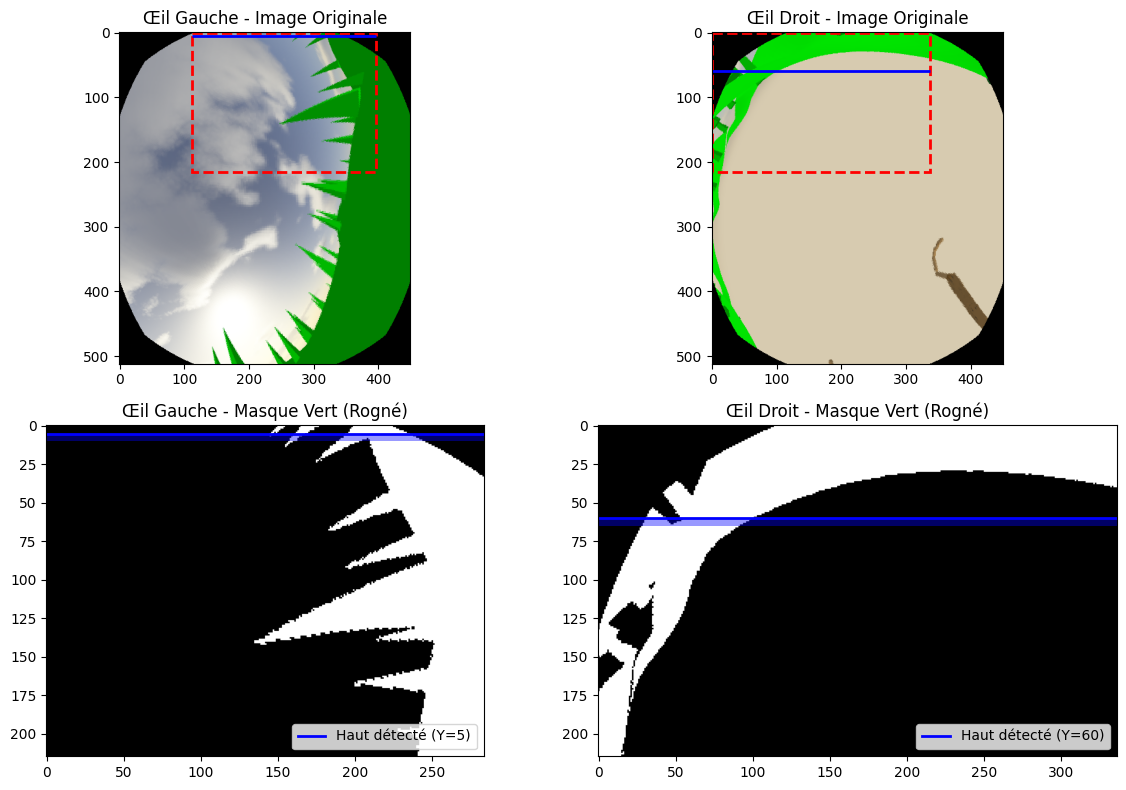

Vision obstacle scores: L=5.0000, R=60.0000
AVOID_OBSTACLE: L=5.0000, R=60.0000
Obstacle binocular → tourner à droite
Obstacle très proche → évitement rapide
(512, 450)
right_eye_score: 0, left_eye_score: 0
Dragonfly head detected: False (Left eye)


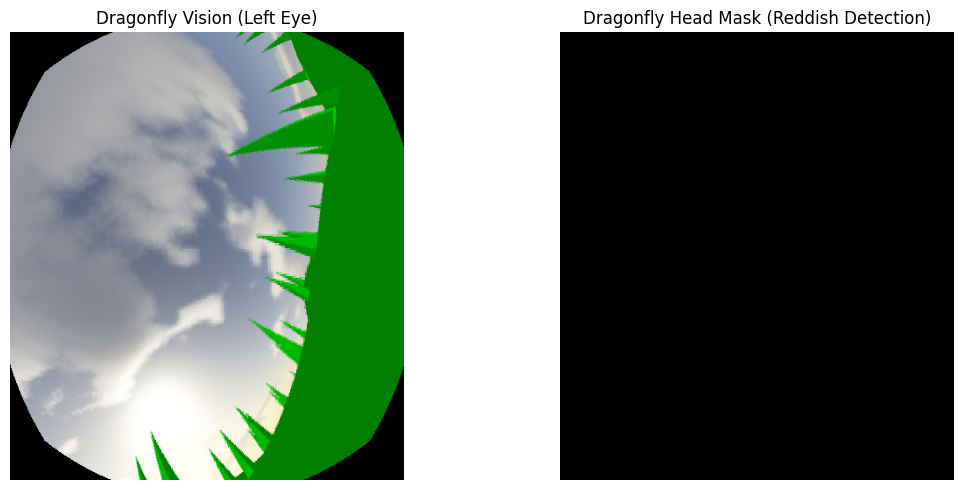

(512, 450)
right_eye_score: 0, left_eye_score: 0
Dragonfly head detected: False (Right eye)


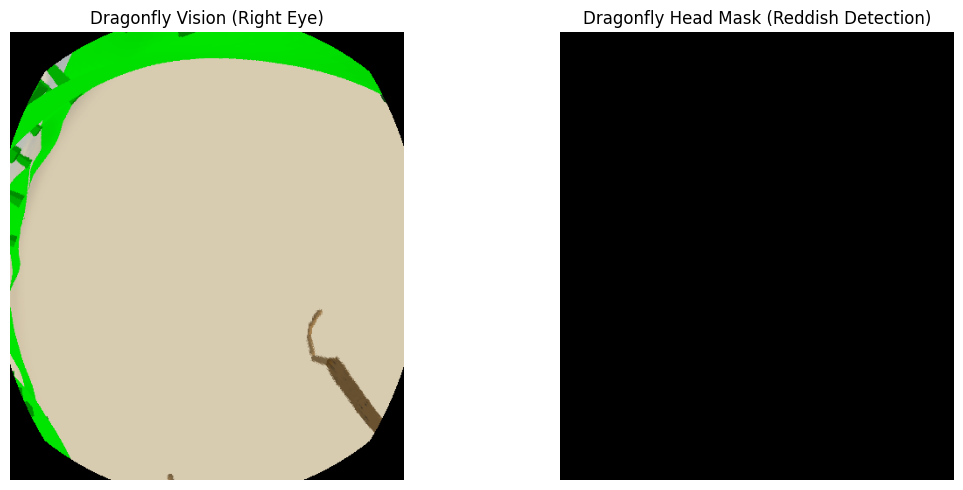

Dragonfly head scores: Left=0, Right=0, Detected=False
Olfaction ratio: 1.0927785670709595e-10
FOLLOW_SCENT: turning left


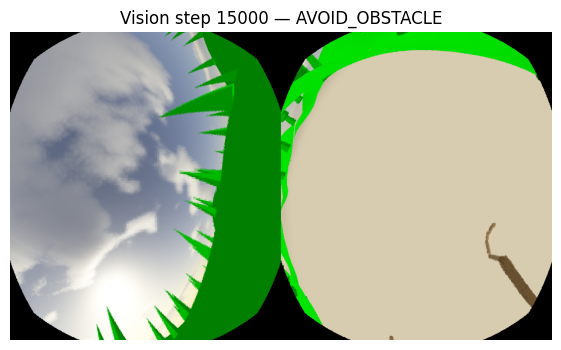

100%|██████████| 20000/20000 [01:06<00:00, 300.93it/s]


nmf/backcam This browser does not support the video tag.


birdeyecam This browser does not support the video tag.


In [1]:
%reload_ext autoreload
%autoreload 2

from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

sim = MiniprojectSimulation(level=4, seed=45)
controller = Controller(sim)

for i in trange(20000):
    joint_angles, adhesion = controller.step(sim, i)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

sim.renderer.show_in_notebook()